# YOLOv8 Tabanlı Derin Öğrenme Yaklaşımlarıyla Beyin Tümörü Tespiti

Bu çalışmada Ultralytics tarafından sağlanan Brain Tumor Detection veri seti kullanılarak beyin görüntülerinden tümör varlığının YOLOv8 tabanlı nesne tespit modeliyle otomatik olarak belirlenmesi amaçlanmıştır.

Çalışma kapsamında veri seti hazırlanmış, sınıf dağılımı analiz edilmiş, örnek görüntüler etiketleriyle birlikte görselleştirilmiş, YOLOv8n modeli transfer öğrenme yaklaşımıyla eğitilmiş ve model başarımı standart nesne tespiti metrikleriyle değerlendirilmiştir.

Kullanılan temel değerlendirme metrikleri şunlardır:

- Accuracy
- Precision
- Recall
- mAP@0.5
- mAP@0.5:0.95
- Confusion Matrix

In [1]:
# YOLOv8 eğitimi, görüntü işleme ve veri analizi için gerekli kütüphaneler yüklenmektedir.

!pip install -q ultralytics opencv-python matplotlib pandas numpy pyyaml scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [1]:
# Çalışma boyunca kullanılacak temel Python kütüphanelerinin içe aktarılması gerçekleştirilmektedir.

import os
import random
import zipfile
from pathlib import Path

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

In [2]:
# Derin öğrenme modelinin GPU üzerinde çalışıp çalışamayacağının kontrol edilmesi sağlanılmıştır.

import torch

print("PyTorch sürümü:", torch.__version__)
print("CUDA kullanılabilir mi?:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Kullanılan GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU bulunamadı. Eğitim CPU üzerinde yürütülecektir ve bu nedenle daha uzun sürebilir.")

PyTorch sürümü: 2.9.1
CUDA kullanılabilir mi?: False
GPU bulunamadı. Eğitim CPU üzerinde yürütülecektir ve bu nedenle daha uzun sürebilir.


In [3]:
# Denemelerin tekrarlanabilir olması için rastgelelik kaynaklarının sabitlenmesi amaçlanmıştır.

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print("Rastgelelik sabitlendi. Kullanılan seed değeri:", SEED)

Rastgelelik sabitlendi. Kullanılan seed değeri: 42


 1. Veri Setinin İndirilmesi ve Hazırlanması

Bu bölümde Brain Tumor Detection veri seti proje klasörüne indirilecek, sıkıştırılmış dosya açılacak ve veri setinin klasör yapısı kontrol edilecektir.

In [4]:
# Proje klasörünün doğru konumda çalışıp çalışmadığının kontrol edilmesi.

from pathlib import Path
import os

PROJECT_DIR = Path.cwd()

print("Mevcut çalışma klasörü:")
print(PROJECT_DIR)

print("\nKlasör içeriği:")
for item in PROJECT_DIR.iterdir():
    print("-", item.name)

Mevcut çalışma klasörü:
/Users/humahumeyraunal/brain_tumor_yolov8_final

Klasör içeriği:
- brain_tumor_yolov8_detection.ipynb
- .ipynb_checkpoints


In [5]:
# Brain Tumor Detection veri setinin Ultralytics bağlantısından indirilmesi.

import urllib.request
import zipfile
from pathlib import Path

DATA_URL = "https://github.com/ultralytics/assets/releases/download/v0.0.0/brain-tumor.zip"
ZIP_PATH = Path("brain-tumor.zip")
DATA_DIR = Path("brain-tumor")

if DATA_DIR.exists():
    print("Veri seti klasörü zaten mevcut:", DATA_DIR)
else:
    print("Veri seti indiriliyor...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    print("İndirme tamamlandı:", ZIP_PATH)

    print("Zip dosyası çıkarılıyor...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(".")

    print("Veri seti başarıyla çıkarıldı.")

Veri seti indiriliyor...
İndirme tamamlandı: brain-tumor.zip
Zip dosyası çıkarılıyor...
Veri seti başarıyla çıkarıldı.


In [8]:
# İndirilen veri setinin klasör yapısının ayrıntılı biçimde incelenmesi.

DATA_DIR = Path("brain-tumor")

for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(str(DATA_DIR), "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{Path(root).name}/")
    
    subindent = " " * 4 * (level + 1)
    for file in files[:5]:
        print(f"{subindent}{file}")

In [9]:
# Zip dosyasından çıkarılan veri seti dosya ve klasörlerinin proje dizininde aranması.

PROJECT_DIR = Path.cwd()

print("Mevcut çalışma klasörü:")
print(PROJECT_DIR)

print("\nProje klasöründeki dosya ve klasörler:")
for item in sorted(PROJECT_DIR.iterdir()):
    print("-", item.name)

Mevcut çalışma klasörü:
/Users/humahumeyraunal/brain_tumor_yolov8_final

Proje klasöründeki dosya ve klasörler:
- .ipynb_checkpoints
- LICENSE.txt
- brain-tumor.yaml
- brain-tumor.zip
- brain_tumor_yolov8_detection.ipynb
- images
- labels


In [10]:
# Veri seti kök dizininin otomatik olarak belirlenmesi.

possible_roots = [
    Path("brain-tumor"),
    Path("."),
    Path("Brain Tumor Detection"),
    Path("brain_tumor"),
]

for root in possible_roots:
    print("\nKontrol edilen dizin:", root)
    print("Dizin var mı?:", root.exists())
    
    if root.exists():
        print("İçerik:")
        for item in sorted(root.iterdir()):
            print(" -", item.name)


Kontrol edilen dizin: brain-tumor
Dizin var mı?: False

Kontrol edilen dizin: .
Dizin var mı?: True
İçerik:
 - .ipynb_checkpoints
 - LICENSE.txt
 - brain-tumor.yaml
 - brain-tumor.zip
 - brain_tumor_yolov8_detection.ipynb
 - images
 - labels

Kontrol edilen dizin: Brain Tumor Detection
Dizin var mı?: False

Kontrol edilen dizin: brain_tumor
Dizin var mı?: False


In [11]:
# Veri setine ait görüntü ve etiket klasörlerinin alt yapısının incelenmesi.

DATA_ROOT = Path(".")
IMAGE_DIR = DATA_ROOT / "images"
LABEL_DIR = DATA_ROOT / "labels"
YAML_PATH = DATA_ROOT / "brain-tumor.yaml"

print("Görüntü klasörü var mı?:", IMAGE_DIR.exists())
print("Etiket klasörü var mı?:", LABEL_DIR.exists())
print("YAML dosyası var mı?:", YAML_PATH.exists())

print("\nImages klasörü içeriği:")
for item in sorted(IMAGE_DIR.iterdir()):
    print("-", item.name)

print("\nLabels klasörü içeriği:")
for item in sorted(LABEL_DIR.iterdir()):
    print("-", item.name)

Görüntü klasörü var mı?: True
Etiket klasörü var mı?: True
YAML dosyası var mı?: True

Images klasörü içeriği:
- train
- val

Labels klasörü içeriği:
- train
- val


In [12]:
# Veri seti yapılandırma dosyasının içeriğinin okunması.

with open(YAML_PATH, "r", encoding="utf-8") as file:
    yaml_data = yaml.safe_load(file)

print("YAML dosyası içeriği:")
print(yaml_data)

YAML dosyası içeriği:
{'path': 'brain-tumor', 'train': 'images/train', 'val': 'images/val', 'test': None, 'names': {0: 'negative', 1: 'positive'}, 'download': 'https://github.com/ultralytics/assets/releases/download/v0.0.0/brain-tumor.zip'}


 2. YAML Dosyasının Proje Yapısına Göre Düzenlenmesi

Bu bölümde veri setinin mevcut klasör yapısına uygun yeni bir YAML dosyası oluşturulacaktır. Böylece YOLOv8 modeli eğitim sırasında görüntü ve etiket dosyalarına doğru şekilde erişebilecektir.

In [13]:
# Veri setinin mevcut proje klasör yapısına uygun yeni YAML dosyasının oluşturulması.

LOCAL_YAML_PATH = Path("brain-tumor-local.yaml")

local_yaml_data = {
    "path": str(Path.cwd()),
    "train": "images/train",
    "val": "images/val",
    "names": {
        0: "negative",
        1: "positive"
    }
}

with open(LOCAL_YAML_PATH, "w", encoding="utf-8") as file:
    yaml.dump(local_yaml_data, file, sort_keys=False, allow_unicode=True)

print("Yeni YAML dosyası oluşturuldu:", LOCAL_YAML_PATH)

Yeni YAML dosyası oluşturuldu: brain-tumor-local.yaml


In [14]:
# Oluşturulan yerel YAML dosyasının içeriğinin kontrol edilmesi.

with open(LOCAL_YAML_PATH, "r", encoding="utf-8") as file:
    print(file.read())

path: /Users/humahumeyraunal/brain_tumor_yolov8_final
train: images/train
val: images/val
names:
  0: negative
  1: positive



In [15]:
# Eğitim ve doğrulama klasörlerindeki görüntü ve etiket sayılarının hesaplanması.

TRAIN_IMAGE_DIR = Path("images/train")
VAL_IMAGE_DIR = Path("images/val")

TRAIN_LABEL_DIR = Path("labels/train")
VAL_LABEL_DIR = Path("labels/val")

image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]

train_images = [p for p in TRAIN_IMAGE_DIR.iterdir() if p.suffix.lower() in image_extensions]
val_images = [p for p in VAL_IMAGE_DIR.iterdir() if p.suffix.lower() in image_extensions]

train_labels = list(TRAIN_LABEL_DIR.glob("*.txt"))
val_labels = list(VAL_LABEL_DIR.glob("*.txt"))

print("Eğitim görüntü sayısı:", len(train_images))
print("Eğitim etiket dosyası sayısı:", len(train_labels))

print("Doğrulama görüntü sayısı:", len(val_images))
print("Doğrulama etiket dosyası sayısı:", len(val_labels))

Eğitim görüntü sayısı: 893
Eğitim etiket dosyası sayısı: 878
Doğrulama görüntü sayısı: 223
Doğrulama etiket dosyası sayısı: 223


In [17]:
# Eğitim setinde etiketi bulunmayan görüntüler için boş etiket dosyalarının oluşturulması.

def create_empty_labels_for_missing_images(image_dir, label_dir):
    image_files = [p for p in Path(image_dir).iterdir() if p.suffix.lower() in image_extensions]
    label_files = list(Path(label_dir).glob("*.txt"))
    
    image_stems = set(p.stem for p in image_files)
    label_stems = set(p.stem for p in label_files)
    
    missing_labels = sorted(image_stems - label_stems)
    
    for stem in missing_labels:
        empty_label_path = Path(label_dir) / f"{stem}.txt"
        empty_label_path.touch()
    
    print("Oluşturulan boş etiket dosyası sayısı:", len(missing_labels))
    print("İlk örnekler:", missing_labels[:10])

create_empty_labels_for_missing_images(TRAIN_IMAGE_DIR, TRAIN_LABEL_DIR)

Oluşturulan boş etiket dosyası sayısı: 15
İlk örnekler: ['00360_108', '00360_114', '00360_115', '00360_120', '00360_122', '00360_126', '00360_129', '00364_107', '00364_113', '00364_119']


In [18]:
# Boş etiket dosyaları oluşturulduktan sonra görüntü-etiket eşleşmesinin yeniden kontrol edilmesi.

train_match = check_image_label_matching(TRAIN_IMAGE_DIR, TRAIN_LABEL_DIR)
val_match = check_image_label_matching(VAL_IMAGE_DIR, VAL_LABEL_DIR)

print("Eğitim veri eşleşme kontrolü:")
print(train_match)

print("\nDoğrulama veri eşleşme kontrolü:")
print(val_match)

Eğitim veri eşleşme kontrolü:
{'image_count': 893, 'label_count': 893, 'missing_label_count': 0, 'extra_label_count': 0, 'missing_labels': [], 'extra_labels': []}

Doğrulama veri eşleşme kontrolü:
{'image_count': 223, 'label_count': 223, 'missing_label_count': 0, 'extra_label_count': 0, 'missing_labels': [], 'extra_labels': []}


In [19]:
# Eğitim ve doğrulama etiket dosyalarında yer alan sınıf dağılımlarının hesaplanması.

def count_class_distribution(label_dir):
    class_counts = {0: 0, 1: 0}
    empty_label_files = 0
    total_boxes = 0
    
    for label_file in Path(label_dir).glob("*.txt"):
        content = label_file.read_text().strip()
        
        if content == "":
            empty_label_files += 1
            continue
        
        for line in content.splitlines():
            parts = line.split()
            
            if len(parts) >= 5:
                class_id = int(parts[0])
                class_counts[class_id] = class_counts.get(class_id, 0) + 1
                total_boxes += 1
    
    return {
        "class_counts": class_counts,
        "empty_label_files": empty_label_files,
        "total_boxes": total_boxes
    }

train_class_distribution = count_class_distribution(TRAIN_LABEL_DIR)
val_class_distribution = count_class_distribution(VAL_LABEL_DIR)

print("Eğitim sınıf dağılımı:")
print(train_class_distribution)

print("\nDoğrulama sınıf dağılımı:")
print(val_class_distribution)

Eğitim sınıf dağılımı:
{'class_counts': {0: 437, 1: 488}, 'empty_label_files': 15, 'total_boxes': 925}

Doğrulama sınıf dağılımı:
{'class_counts': {0: 154, 1: 87}, 'empty_label_files': 0, 'total_boxes': 241}


In [20]:
# Sınıf dağılımlarının tablo formatında gösterilmesi.

class_names = {
    0: "negative",
    1: "positive"
}

distribution_rows = []

for class_id, class_name in class_names.items():
    distribution_rows.append({
        "Veri Bölümü": "Eğitim",
        "Sınıf ID": class_id,
        "Sınıf Adı": class_name,
        "Etiket Sayısı": train_class_distribution["class_counts"].get(class_id, 0)
    })
    
    distribution_rows.append({
        "Veri Bölümü": "Doğrulama",
        "Sınıf ID": class_id,
        "Sınıf Adı": class_name,
        "Etiket Sayısı": val_class_distribution["class_counts"].get(class_id, 0)
    })

df_class_distribution = pd.DataFrame(distribution_rows)
df_class_distribution

,Veri Bölümü,Sınıf ID,Sınıf Adı,Etiket Sayısı
0,Eğitim,0,negative,437
1,Doğrulama,0,negative,154
2,Eğitim,1,positive,488
3,Doğrulama,1,positive,87


# 3. Veri Seti Analizi ve Görselleştirme

Bu bölümde sınıf dağılımları grafiksel olarak incelenecek ve veri setinden örnek görüntüler etiket kutuları ile birlikte görselleştirilecektir. Bu adım, model eğitiminden önce veri setinin yapısının anlaşılması açısından önemlidir.

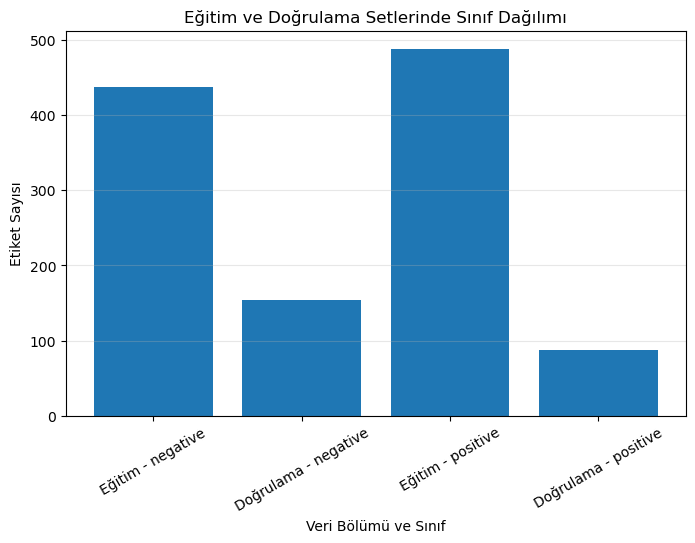

In [21]:
# Sınıf dağılımlarının grafiksel olarak gösterilmesi.

plt.figure(figsize=(8, 5))

x_labels = df_class_distribution["Veri Bölümü"] + " - " + df_class_distribution["Sınıf Adı"]
y_values = df_class_distribution["Etiket Sayısı"]

plt.bar(x_labels, y_values)
plt.title("Eğitim ve Doğrulama Setlerinde Sınıf Dağılımı")
plt.xlabel("Veri Bölümü ve Sınıf")
plt.ylabel("Etiket Sayısı")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [22]:
# Boş etiket dosyalarının sayısının tablo halinde gösterilmesi.

empty_label_summary = pd.DataFrame([
    {
        "Veri Bölümü": "Eğitim",
        "Boş Etiket Dosyası Sayısı": train_class_distribution["empty_label_files"],
        "Toplam Nesne Kutusu": train_class_distribution["total_boxes"]
    },
    {
        "Veri Bölümü": "Doğrulama",
        "Boş Etiket Dosyası Sayısı": val_class_distribution["empty_label_files"],
        "Toplam Nesne Kutusu": val_class_distribution["total_boxes"]
    }
])

empty_label_summary

,Veri Bölümü,Boş Etiket Dosyası Sayısı,Toplam Nesne Kutusu
0,Eğitim,15,925
1,Doğrulama,0,241


In [24]:
# YOLO formatındaki etiketlerin görüntü üzerine kutu olarak çizdirilmesi için yardımcı fonksiyon tanımlanması.

def draw_yolo_boxes(image_path, label_path, class_names):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    height, width, _ = image.shape
    
    if Path(label_path).exists():
        label_content = Path(label_path).read_text().strip()
        
        if label_content != "":
            for line in label_content.splitlines():
                parts = line.split()
                
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    x_center, y_center, box_width, box_height = map(float, parts[1:5])
                    
                    x1 = int((x_center - box_width / 2) * width)
                    y1 = int((y_center - box_height / 2) * height)
                    x2 = int((x_center + box_width / 2) * width)
                    y2 = int((y_center + box_height / 2) * height)
                    
                    cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
                    cv2.putText(
                        image,
                        class_names[class_id],
                        (x1, max(y1 - 10, 20)),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6,
                        (255, 0, 0),
                        2
                    )
    
    return image

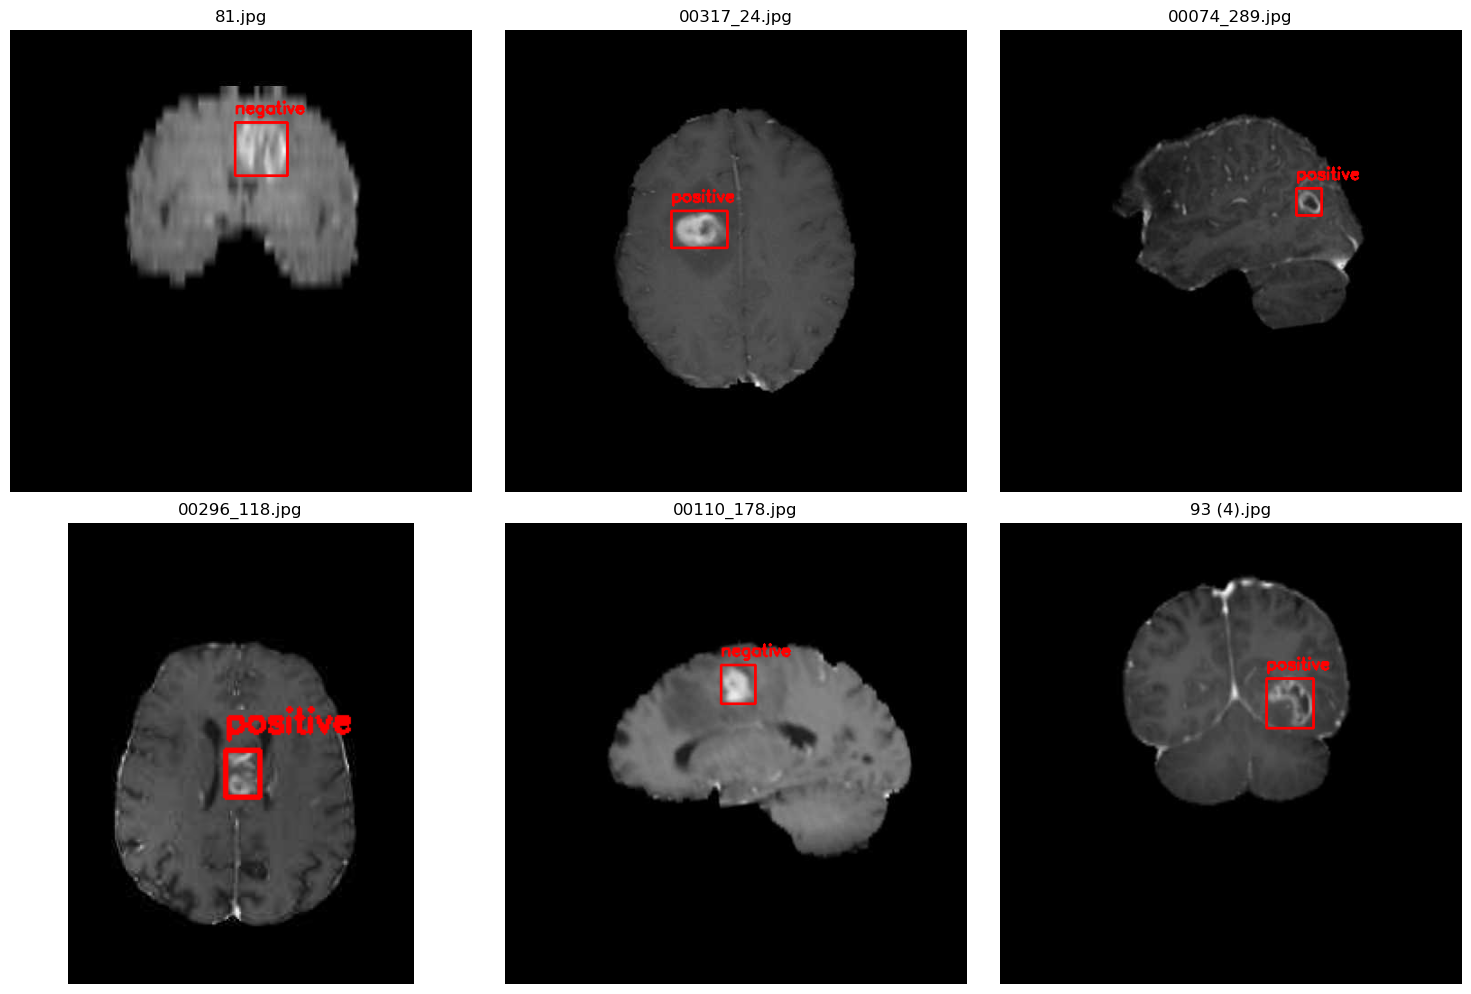

In [25]:
# Eğitim setinden seçilen örnek görüntülerin etiket kutuları ile birlikte görselleştirilmesi.

sample_train_images = random.sample(train_images, 6)

plt.figure(figsize=(15, 10))

for index, image_path in enumerate(sample_train_images):
    label_path = TRAIN_LABEL_DIR / f"{image_path.stem}.txt"
    image_with_boxes = draw_yolo_boxes(image_path, label_path, class_names)
    
    plt.subplot(2, 3, index + 1)
    plt.imshow(image_with_boxes)
    plt.title(image_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

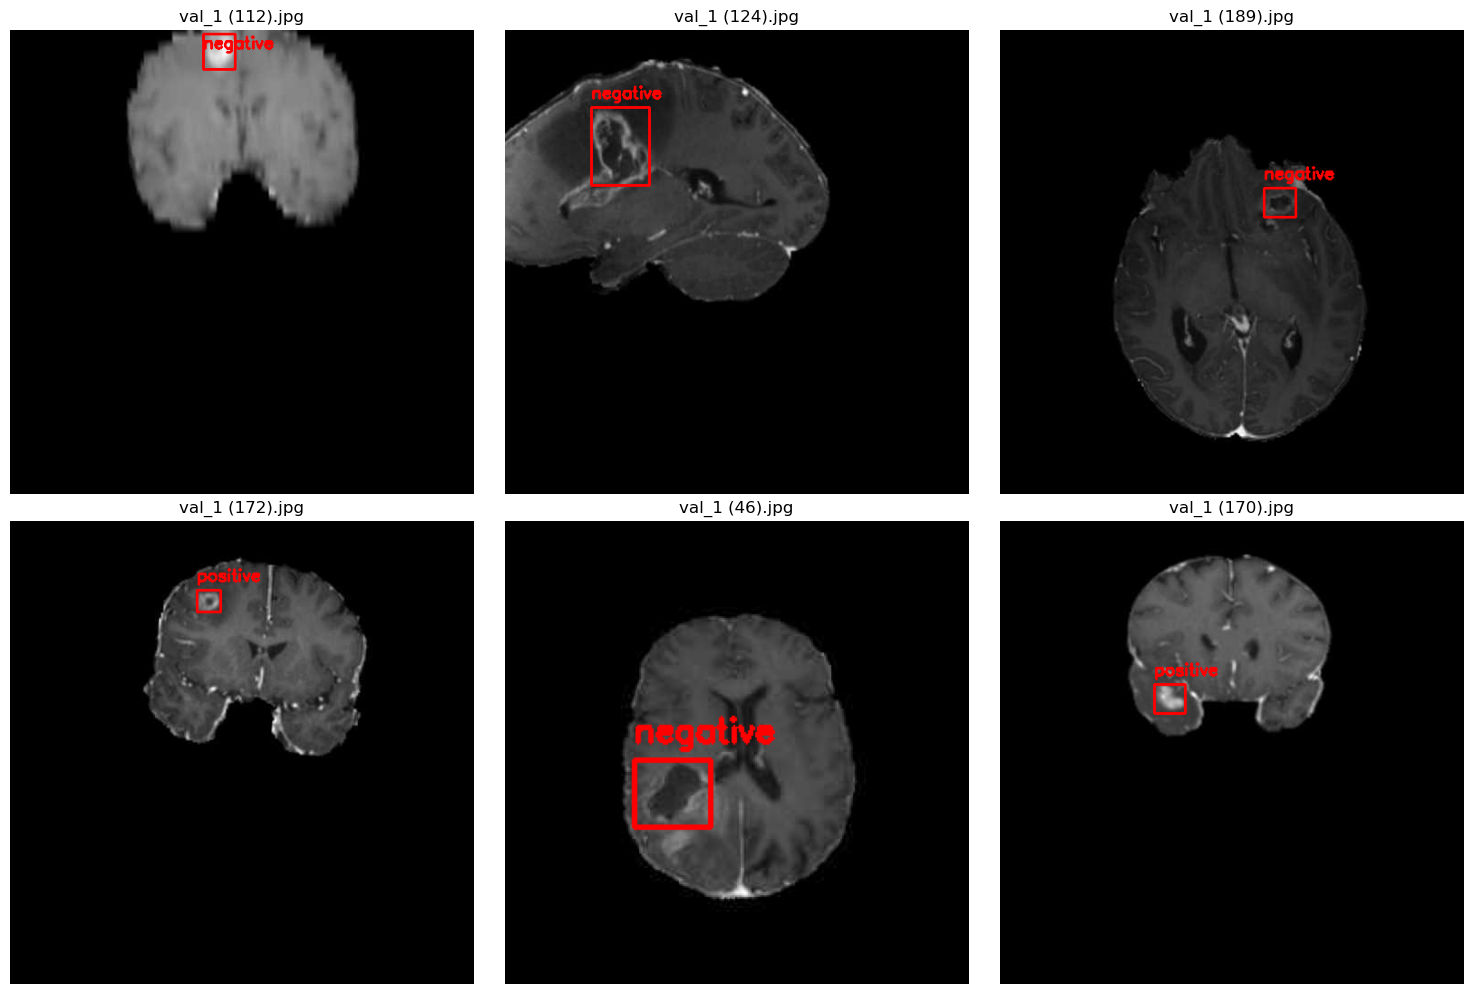

In [26]:
# Doğrulama setinden seçilen örnek görüntülerin etiket kutuları ile birlikte görselleştirilmesi.

sample_val_images = random.sample(val_images, 6)

plt.figure(figsize=(15, 10))

for index, image_path in enumerate(sample_val_images):
    label_path = VAL_LABEL_DIR / f"{image_path.stem}.txt"
    image_with_boxes = draw_yolo_boxes(image_path, label_path, class_names)
    
    plt.subplot(2, 3, index + 1)
    plt.imshow(image_with_boxes)
    plt.title(image_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# 4. YOLOv8n Modeli ile Ön Eğitim Kontrolü

Bu bölümde YOLOv8n modeli kullanılarak kısa bir eğitim denemesi yapılacaktır. Bu adım, veri seti yolunun, YAML dosyasının ve YOLOv8 eğitim sürecinin doğru çalışıp çalışmadığını kontrol etmek amacıyla uygulanmaktadır.;

In [27]:
# YOLOv8n modeli ile kısa süreli eğitim denemesinin gerçekleştirilmesi.

test_model = YOLO("yolov8n.pt")

test_results = test_model.train(
    data=str(LOCAL_YAML_PATH),
    epochs=3,
    imgsz=416,
    batch=4,
    device="cpu",
    project="runs_brain_tumor",
    name="yolov8n_test_run",
    seed=SEED,
    pretrained=True,
    patience=2,
    workers=0
)

New https://pypi.org/project/ultralytics/8.4.75 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.231 🚀 Python-3.13.5 torch-2.9.1 CPU (Apple M3)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=brain-tumor-local.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_test_run, nbs=64, nms=False, opset=None, optimize=False, o

# 5. YOLOv8n Modeli ile Ana Eğitim Süreci

Bu bölümde YOLOv8n modeli, transfer öğrenme yaklaşımıyla Brain Tumor Detection veri seti üzerinde eğitilecektir. Ön test aşamasında veri seti yolunun ve eğitim sürecinin doğru çalıştığı doğrulandığı için bu aşamada daha uzun süreli ana eğitim gerçekleştirilecektir.

Model eğitimi sırasında önceden eğitilmiş `yolov8n.pt` ağırlıkları kullanılacaktır. Böylece model, genel görüntü özelliklerini öğrenmiş bir başlangıç noktasından medikal görüntülerde tümör tespiti görevine uyarlanacaktır.

In [28]:
# YOLOv8n modeli ile ana eğitim sürecinin gerçekleştirilmesi.

baseline_model = YOLO("yolov8n.pt")

baseline_results = baseline_model.train(
    data=str(LOCAL_YAML_PATH),
    epochs=50,
    imgsz=416,
    batch=4,
    device="cpu",
    project="runs_brain_tumor",
    name="yolov8n_baseline_50epoch",
    seed=SEED,
    pretrained=True,
    patience=10,
    workers=0,
    optimizer="AdamW",
    plots=True
)

New https://pypi.org/project/ultralytics/8.4.75 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.231 🚀 Python-3.13.5 torch-2.9.1 CPU (Apple M3)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=brain-tumor-local.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_baseline_50epoch, nbs=64, nms=False, opset=None, optimize

# 6. Model Değerlendirme Sonuçları

Bu bölümde ana eğitim sonucunda elde edilen en iyi YOLOv8n modeli değerlendirilecektir. Eğitim sürecinde erken durdurma mekanizması devreye girmiş ve en iyi model ağırlıkları `best.pt` dosyası olarak kaydedilmiştir.

Değerlendirme aşamasında precision, recall, mAP@0.5 ve mAP@0.5:0.95 metrikleri incelenecektir.

In [29]:
# Ana eğitim sonucunda kaydedilen en iyi model ağırlık dosyasının kontrol edilmesi.

BEST_MODEL_PATH = Path("runs_brain_tumor/yolov8n_baseline_50epoch/weights/best.pt")
LAST_MODEL_PATH = Path("runs_brain_tumor/yolov8n_baseline_50epoch/weights/last.pt")
RESULTS_DIR = Path("runs_brain_tumor/yolov8n_baseline_50epoch")

print("Best model dosyası var mı?:", BEST_MODEL_PATH.exists())
print("Last model dosyası var mı?:", LAST_MODEL_PATH.exists())
print("Sonuç klasörü var mı?:", RESULTS_DIR.exists())

print("\nSonuç klasörü içeriği:")
for item in sorted(RESULTS_DIR.iterdir()):
    print("-", item.name)

Best model dosyası var mı?: True
Last model dosyası var mı?: True
Sonuç klasörü var mı?: True

Sonuç klasörü içeriği:
- BoxF1_curve.png
- BoxPR_curve.png
- BoxP_curve.png
- BoxR_curve.png
- args.yaml
- confusion_matrix.png
- confusion_matrix_normalized.png
- labels.jpg
- results.csv
- results.png
- train_batch0.jpg
- train_batch1.jpg
- train_batch2.jpg
- val_batch0_labels.jpg
- val_batch0_pred.jpg
- val_batch1_labels.jpg
- val_batch1_pred.jpg
- val_batch2_labels.jpg
- val_batch2_pred.jpg
- weights


In [30]:
# Eğitim sürecinde kaydedilen sonuç dosyasının tablo olarak okunması.

RESULTS_CSV_PATH = RESULTS_DIR / "results.csv"

df_results = pd.read_csv(RESULTS_CSV_PATH)
df_results.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,63.3317,1.71978,2.12706,1.40387,0.35143,0.42495,0.25203,0.12261,1.79019,18.09130,1.73699,0.070134,0.003318,0.003318
1,2,121.8660,1.69734,1.87803,1.46806,0.36987,0.40450,0.24968,0.13148,1.50095,4.46855,1.38825,0.040002,0.006520,0.006520
2,3,187.4460,1.60329,1.69839,1.40665,0.39362,0.59191,0.43365,0.24358,1.43350,1.56138,1.38663,0.009739,0.009590,0.009590
3,4,266.5850,1.51228,1.58586,1.34687,0.44961,0.65125,0.45003,0.27465,1.40072,1.52529,1.28127,0.009406,0.009406,0.009406
4,5,340.9810,1.47278,1.54401,1.29197,0.42551,0.75418,0.46015,0.29780,1.27568,1.41284,1.25993,0.009208,0.009208,0.009208


In [31]:
# Eğitim sonuç tablosundaki sütun adlarının incelenmesi.

df_results.columns

Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')

In [32]:
# mAP@0.5:0.95 değerine göre en iyi epoch sonucunun belirlenmesi.

best_epoch_row = df_results.loc[df_results["metrics/mAP50-95(B)"].idxmax()]

best_epoch_summary = pd.DataFrame([{
    "En İyi Epoch": int(best_epoch_row["epoch"]),
    "Precision": best_epoch_row["metrics/precision(B)"],
    "Recall": best_epoch_row["metrics/recall(B)"],
    "mAP@0.5": best_epoch_row["metrics/mAP50(B)"],
    "mAP@0.5:0.95": best_epoch_row["metrics/mAP50-95(B)"],
    "Train Box Loss": best_epoch_row["train/box_loss"],
    "Train Class Loss": best_epoch_row["train/cls_loss"],
    "Train DFL Loss": best_epoch_row["train/dfl_loss"]
}])

best_epoch_summary

,En İyi Epoch,Precision,Recall,mAP@0.5,mAP@0.5:0.95,Train Box Loss,Train Class Loss,Train DFL Loss
0,24,0.4633,0.84108,0.50425,0.35737,1.14415,1.18471,1.12061


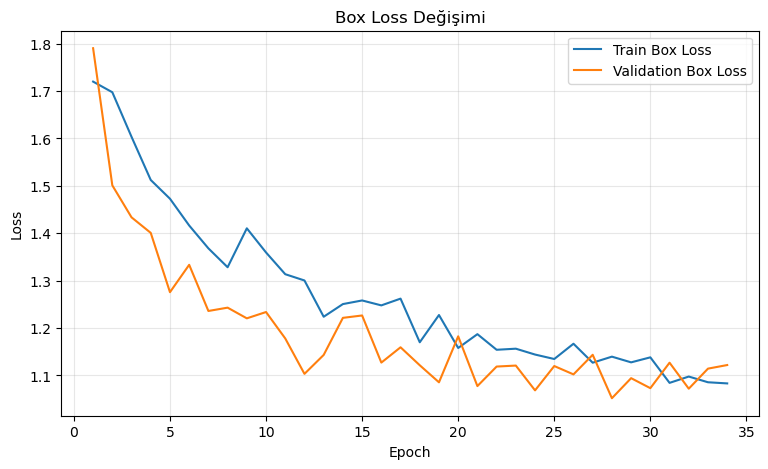

In [33]:
# Eğitim ve doğrulama kayıp değerlerinin epoch bazında görselleştirilmesi.

plt.figure(figsize=(9, 5))

plt.plot(df_results["epoch"], df_results["train/box_loss"], label="Train Box Loss")
plt.plot(df_results["epoch"], df_results["val/box_loss"], label="Validation Box Loss")

plt.title("Box Loss Değişimi")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

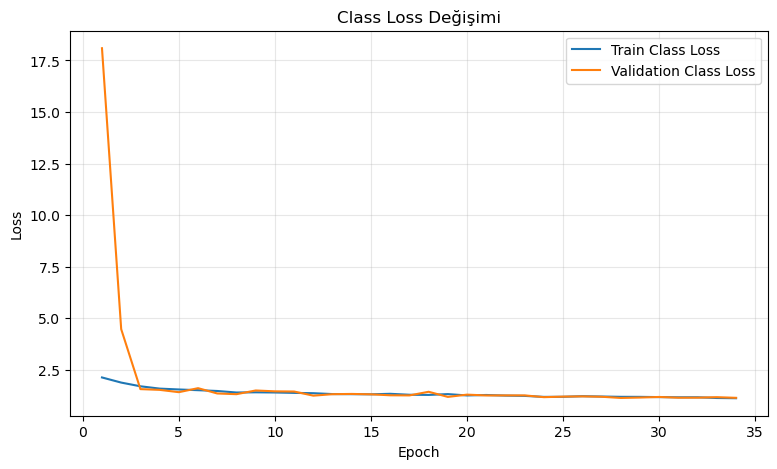

In [34]:
# Sınıflandırma kayıp değerlerinin epoch bazında görselleştirilmesi.

plt.figure(figsize=(9, 5))

plt.plot(df_results["epoch"], df_results["train/cls_loss"], label="Train Class Loss")
plt.plot(df_results["epoch"], df_results["val/cls_loss"], label="Validation Class Loss")

plt.title("Class Loss Değişimi")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

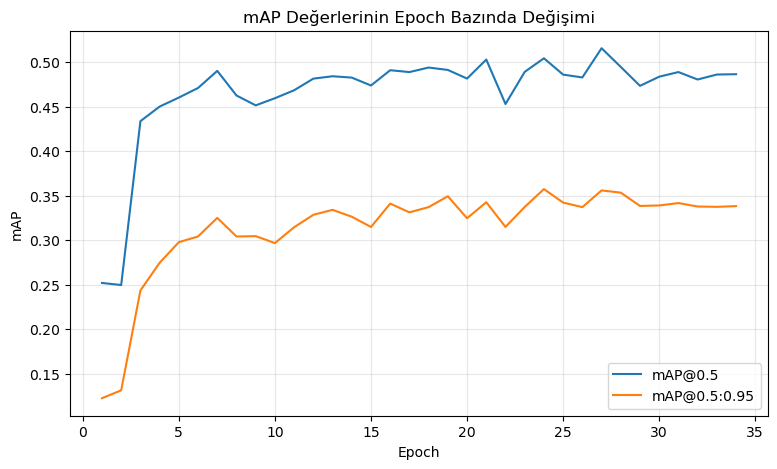

In [35]:
# mAP değerlerinin epoch bazında görselleştirilmesi.

plt.figure(figsize=(9, 5))

plt.plot(df_results["epoch"], df_results["metrics/mAP50(B)"], label="mAP@0.5")
plt.plot(df_results["epoch"], df_results["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")

plt.title("mAP Değerlerinin Epoch Bazında Değişimi")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [36]:
# Eğitim sürecinde Ultralytics tarafından oluşturulan görsel çıktıların listelenmesi.

image_outputs = list(RESULTS_DIR.glob("*.png")) + list(RESULTS_DIR.glob("*.jpg"))

for image_file in image_outputs:
    print(image_file)

runs_brain_tumor/yolov8n_baseline_50epoch/confusion_matrix.png
runs_brain_tumor/yolov8n_baseline_50epoch/results.png
runs_brain_tumor/yolov8n_baseline_50epoch/BoxR_curve.png
runs_brain_tumor/yolov8n_baseline_50epoch/confusion_matrix_normalized.png
runs_brain_tumor/yolov8n_baseline_50epoch/BoxF1_curve.png
runs_brain_tumor/yolov8n_baseline_50epoch/BoxP_curve.png
runs_brain_tumor/yolov8n_baseline_50epoch/BoxPR_curve.png
runs_brain_tumor/yolov8n_baseline_50epoch/val_batch1_labels.jpg
runs_brain_tumor/yolov8n_baseline_50epoch/val_batch2_pred.jpg
runs_brain_tumor/yolov8n_baseline_50epoch/val_batch0_labels.jpg
runs_brain_tumor/yolov8n_baseline_50epoch/train_batch0.jpg
runs_brain_tumor/yolov8n_baseline_50epoch/train_batch1.jpg
runs_brain_tumor/yolov8n_baseline_50epoch/train_batch2.jpg
runs_brain_tumor/yolov8n_baseline_50epoch/val_batch1_pred.jpg
runs_brain_tumor/yolov8n_baseline_50epoch/val_batch0_pred.jpg
runs_brain_tumor/yolov8n_baseline_50epoch/labels.jpg
runs_brain_tumor/yolov8n_baseline_5

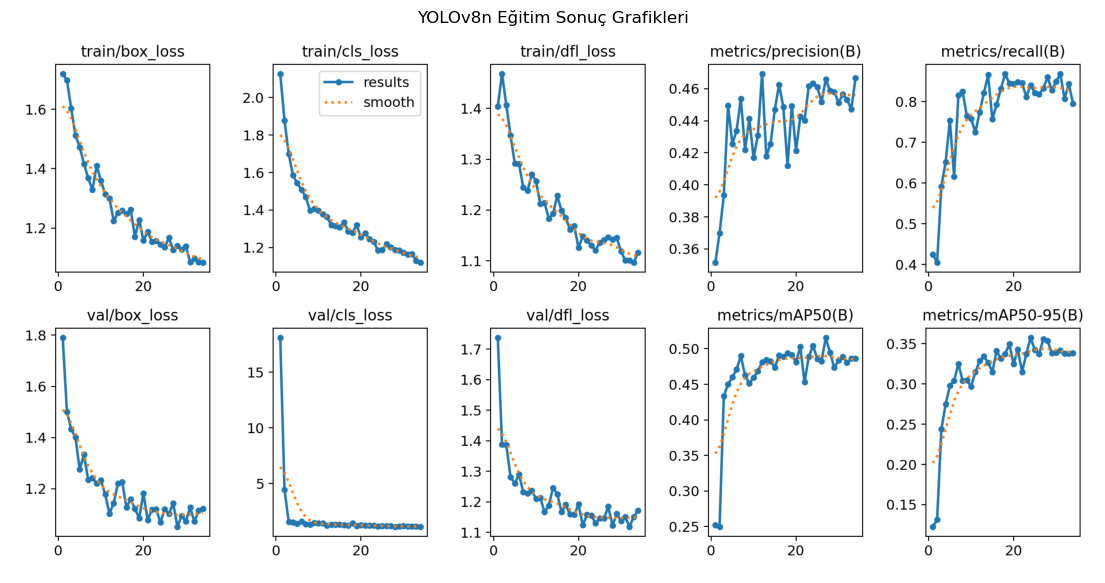

In [37]:
# Eğitim sonuç grafiğinin notebook içinde gösterilmesi.

results_image_path = RESULTS_DIR / "results.png"

if results_image_path.exists():
    image = cv2.imread(str(results_image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title("YOLOv8n Eğitim Sonuç Grafikleri")
    plt.show()
else:
    print("results.png dosyası bulunamadı.")

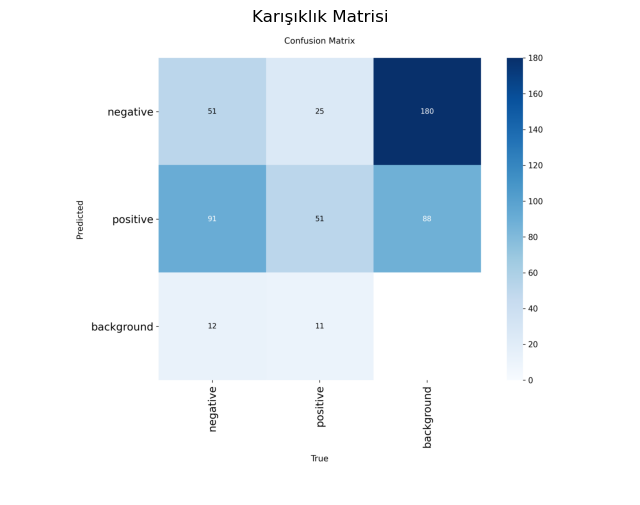

In [38]:
# Karışıklık matrisinin notebook içinde gösterilmesi.

confusion_matrix_path = RESULTS_DIR / "confusion_matrix.png"

if confusion_matrix_path.exists():
    image = cv2.imread(str(confusion_matrix_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Karışıklık Matrisi")
    plt.show()
else:
    print("confusion_matrix.png dosyası bulunamadı.")

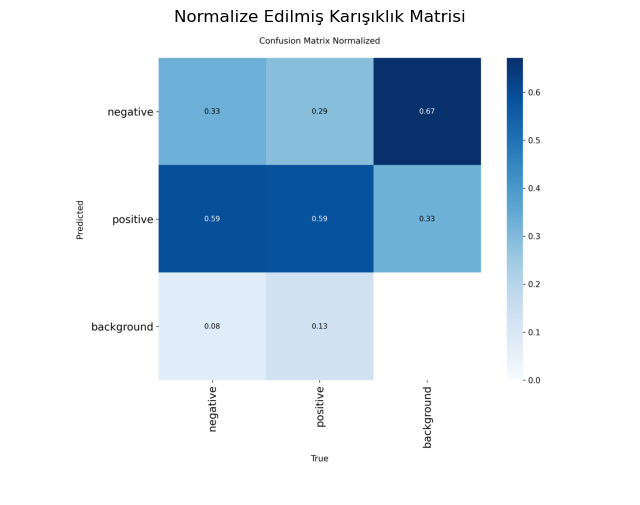

In [39]:
# Normalize edilmiş karışıklık matrisinin notebook içinde gösterilmesi.

confusion_matrix_normalized_path = RESULTS_DIR / "confusion_matrix_normalized.png"

if confusion_matrix_normalized_path.exists():
    image = cv2.imread(str(confusion_matrix_normalized_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Normalize Edilmiş Karışıklık Matrisi")
    plt.show()
else:
    print("confusion_matrix_normalized.png dosyası bulunamadı.")

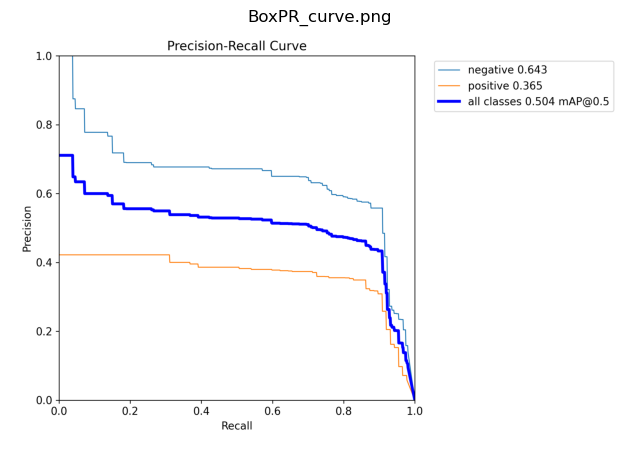

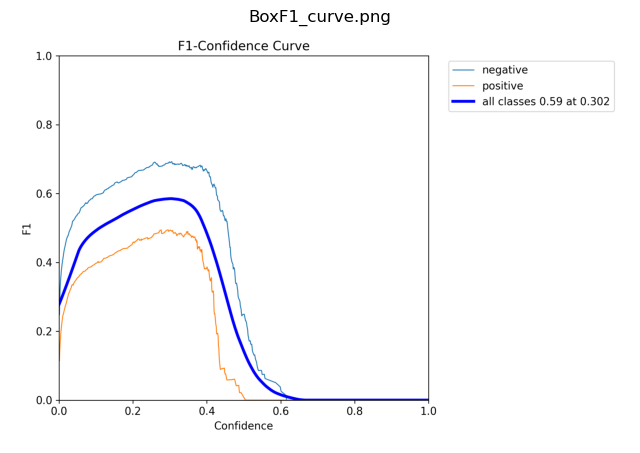

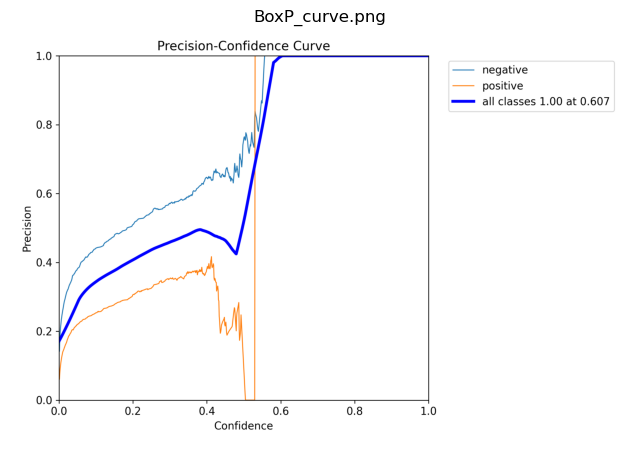

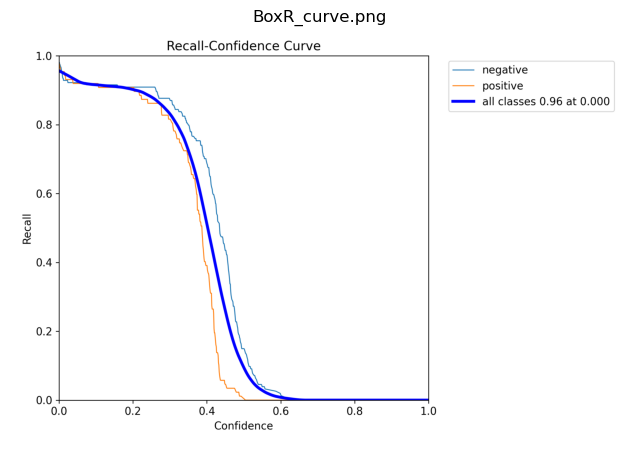

In [40]:
# YOLOv8 tarafından oluşturulan performans eğrilerinin notebook içinde gösterilmesi.

curve_files = [
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png"
]

for curve_file in curve_files:
    curve_path = RESULTS_DIR / curve_file
    
    if curve_path.exists():
        image = cv2.imread(str(curve_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(8, 6))
        plt.imshow(image)
        plt.axis("off")
        plt.title(curve_file)
        plt.show()
    else:
        print(f"{curve_file} dosyası bulunamadı.")

In [41]:
# En iyi model ağırlıkları kullanılarak doğrulama seti üzerinde nihai değerlendirme yapılması.

best_model = YOLO(str(BEST_MODEL_PATH))

final_validation_results = best_model.val(
    data=str(LOCAL_YAML_PATH),
    imgsz=416,
    batch=4,
    device="cpu",
    workers=0,
    project="runs_brain_tumor",
    name="yolov8n_best_final_validation",
    plots=True
)

Ultralytics 8.3.231 🚀 Python-3.13.5 torch-2.9.1 CPU (Apple M3)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 20.5±7.2 MB/s, size: 3.8 KB)
val: Scanning /Users/humahumeyraunal/brain_tumor_yolov8_final/labels/val.cache... 223 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 223/223 808.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 12.9it/s 4.3s0.2s
                   all        223        241      0.463      0.841      0.504      0.358
              negative        142        154      0.573       0.87      0.643       0.45
              positive         81         87      0.354      0.812      0.365      0.265
Speed: 0.2ms preprocess, 17.8ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /Users/humahumeyraunal/brain_tumor_yolov8_final/runs_brain_tumor/yolov8n_best_final_validation


In [42]:
# Nihai doğrulama metriklerinin tablo formatında özetlenmesi.

final_metrics_summary = pd.DataFrame([{
    "Model": "YOLOv8n",
    "En İyi Epoch": int(best_epoch_row["epoch"]),
    "Precision": round(float(best_epoch_row["metrics/precision(B)"]), 4),
    "Recall": round(float(best_epoch_row["metrics/recall(B)"]), 4),
    "mAP@0.5": round(float(best_epoch_row["metrics/mAP50(B)"]), 4),
    "mAP@0.5:0.95": round(float(best_epoch_row["metrics/mAP50-95(B)"]), 4),
    "Eğitim Görüntüsü": len(train_images),
    "Doğrulama Görüntüsü": len(val_images)
}])

final_metrics_summary

,Model,En İyi Epoch,Precision,Recall,mAP@0.5,mAP@0.5:0.95,Eğitim Görüntüsü,Doğrulama Görüntüsü
0,YOLOv8n,24,0.4633,0.8411,0.5042,0.3574,893,223


Değerlendirme Sonuçlarının Yorumu

Ana eğitim sonucunda en iyi model 24. epoch'ta elde edilmiştir. Modelin recall değerinin precision değerinden yüksek olması, modelin etiketli bölgeleri yakalama eğiliminin güçlü olduğunu; ancak bazı yanlış pozitif tahminler üretme olasılığının bulunduğunu göstermektedir.

mAP@0.5 değerinin yaklaşık 0.50 düzeyinde olması, modelin temel nesne tespiti görevini öğrendiğini göstermektedir. Bununla birlikte mAP@0.5:0.95 değerinin daha düşük olması, daha sıkı IoU eşiklerinde kutu konumlandırma başarısının sınırlı kaldığını ortaya koymaktadır.

Karışıklık matrisi incelendiğinde negative ve positive sınıfları arasında karışmalar olduğu ve background sınıfında da önemli sayıda hatalı/eksik tespit bulunduğu görülmektedir. Bu nedenle model klinik karar verme sürecinde tek başına kullanılabilecek kesinlikte değildir; ancak beyin MR görüntülerinde ön tespit ve karar destek amacıyla geliştirilebilecek bir başlangıç modeli olarak değerlendirilebilir.

Görüntü Bazlı Accuracy Hesaplaması

YOLOv8 nesne tespiti modellerinde temel değerlendirme metrikleri precision, recall ve mAP değerleridir. Ancak ödevde accuracy metriği de istendiği için doğrulama setindeki her görüntü için gerçek sınıf ile modelin en yüksek güven skoruna sahip tahmini karşılaştırılarak görüntü bazlı accuracy değeri hesaplanmıştır.

In [54]:
# Doğrulama seti üzerinde görüntü bazlı accuracy değerinin hesaplanması.

ACCURACY_CONFIDENCE = 0.25

accuracy_prediction_results = best_model.predict(
    source=[str(image_path) for image_path in val_images],
    imgsz=416,
    conf=ACCURACY_CONFIDENCE,
    iou=0.5,
    device="cpu",
    save=False,
    verbose=False
)

accuracy_rows = []

for image_path, result in zip(val_images, accuracy_prediction_results):
    image_name = Path(image_path).name
    label_path = VAL_LABEL_DIR / f"{Path(image_path).stem}.txt"

    true_class = None
    predicted_class = None
    predicted_confidence = None

    if label_path.exists():
        label_content = label_path.read_text().strip()

        if label_content != "":
            first_label_line = label_content.splitlines()[0]
            true_class = int(first_label_line.split()[0])

    if result.boxes is not None and len(result.boxes) > 0:
        confidence_values = result.boxes.conf.tolist()
        best_prediction_index = int(np.argmax(confidence_values))

        predicted_class = int(result.boxes.cls[best_prediction_index])
        predicted_confidence = float(result.boxes.conf[best_prediction_index])

    is_correct = true_class == predicted_class

    accuracy_rows.append({
        "Görüntü": image_name,
        "Gerçek Sınıf ID": true_class,
        "Gerçek Sınıf": class_names.get(true_class, "Bilinmiyor") if true_class is not None else "Etiket yok",
        "Tahmin Edilen Sınıf ID": predicted_class,
        "Tahmin Edilen Sınıf": class_names.get(predicted_class, "Tespit yok") if predicted_class is not None else "Tespit yok",
        "Güven Skoru": round(predicted_confidence, 4) if predicted_confidence is not None else None,
        "Doğru Tahmin": is_correct
    })

df_accuracy = pd.DataFrame(accuracy_rows)

accuracy_value = df_accuracy["Doğru Tahmin"].mean()

print("Görüntü bazlı accuracy:", round(accuracy_value, 4))
print("Doğru tahmin sayısı:", df_accuracy["Doğru Tahmin"].sum())
print("Toplam görüntü sayısı:", len(df_accuracy))

df_accuracy.head()

Görüntü bazlı accuracy: 0.5964
Doğru tahmin sayısı: 133
Toplam görüntü sayısı: 223


,Görüntü,Gerçek Sınıf ID,Gerçek Sınıf,Tahmin Edilen Sınıf ID,Tahmin Edilen Sınıf,Güven Skoru,Doğru Tahmin
0,val_1 (144).jpg,1,positive,0.0,negative,0.4346,False
1,val_1 (87).jpg,1,positive,0.0,negative,0.4871,False
2,val_1 (113).jpg,0,negative,0.0,negative,0.4208,True
3,val_1 (68).jpg,1,positive,0.0,negative,0.4317,False
4,val_1 (105).jpg,1,positive,0.0,negative,0.4124,False


In [55]:
# Accuracy sonucunun tablo halinde özetlenmesi.

accuracy_summary = pd.DataFrame([{
    "Model": "YOLOv8n",
    "Accuracy": round(accuracy_value, 4),
    "Doğru Tahmin Sayısı": int(df_accuracy["Doğru Tahmin"].sum()),
    "Toplam Görüntü Sayısı": len(df_accuracy),
    "Güven Eşiği": ACCURACY_CONFIDENCE
}])

accuracy_summary

,Model,Accuracy,Doğru Tahmin Sayısı,Toplam Görüntü Sayısı,Güven Eşiği
0,YOLOv8n,0.5964,133,223,0.25


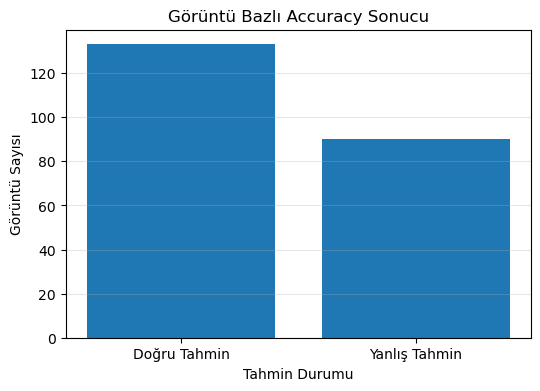

In [56]:
# Doğru ve yanlış tahmin sayılarının görselleştirilmesi.

accuracy_counts = df_accuracy["Doğru Tahmin"].value_counts().rename({
    True: "Doğru Tahmin",
    False: "Yanlış Tahmin"
})

plt.figure(figsize=(6, 4))
plt.bar(accuracy_counts.index, accuracy_counts.values)
plt.title("Görüntü Bazlı Accuracy Sonucu")
plt.xlabel("Tahmin Durumu")
plt.ylabel("Görüntü Sayısı")
plt.grid(axis="y", alpha=0.3)
plt.show()

Görüntü bazlı accuracy değeri, doğrulama setindeki her görüntü için modelin en yüksek güven skoruna sahip tahmini ile gerçek etiketin karşılaştırılmasıyla hesaplanmıştır. Bu metrik, nesne tespiti problemlerinde mAP kadar temel bir ölçüt olmasa da modelin görüntü düzeyinde doğru sınıf tahmini yapma başarısını destekleyici bir değerlendirme olarak kullanılmıştır.

7. En İyi Model ile Tahminlerin Görselleştirilmesi

Bu bölümde ana eğitim sonucunda elde edilen `best.pt` ağırlıkları kullanılarak doğrulama setinden seçilen örnek MR görüntüleri üzerinde tahmin yapılacaktır. Tahmin sonuçları, modelin gerçek görüntüler üzerinde pozitif ve negatif sınıfları nasıl tespit ettiğini görsel olarak incelemek amacıyla kullanılacaktır.

In [43]:
# En iyi model ağırlıkları kullanılarak doğrulama setinden seçilen örnek görüntüler üzerinde tahmin yapılması.

best_model = YOLO(str(BEST_MODEL_PATH))

sample_prediction_images = random.sample(val_images, 8)

prediction_results = best_model.predict(
    source=[str(image_path) for image_path in sample_prediction_images],
    imgsz=416,
    conf=0.25,
    iou=0.5,
    device="cpu",
    save=True,
    project="runs_brain_tumor",
    name="yolov8n_prediction_examples"
)

print("Tahmin işlemi tamamlandı.")


0: 416x416 1 negative, 18.1ms
1: 416x416 1 negative, 18.1ms
2: 416x416 1 negative, 18.1ms
3: 416x416 1 negative, 18.1ms
4: 416x416 1 negative, 18.1ms
5: 416x416 1 negative, 1 positive, 18.1ms
6: 416x416 1 negative, 18.1ms
7: 416x416 2 negatives, 2 positives, 18.1ms
Speed: 0.8ms preprocess, 18.1ms inference, 0.5ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /Users/humahumeyraunal/brain_tumor_yolov8_final/runs_brain_tumor/yolov8n_prediction_examples
Tahmin işlemi tamamlandı.


In [44]:
# Tahmin sonuçlarının kaydedildiği klasörün ve görsel dosyaların kontrol edilmesi.

PREDICTION_DIR = Path("runs_brain_tumor/yolov8n_prediction_examples")

print("Tahmin klasörü var mı?:", PREDICTION_DIR.exists())

prediction_image_files = sorted(
    list(PREDICTION_DIR.glob("*.jpg")) +
    list(PREDICTION_DIR.glob("*.png"))
)

print("Tahmin görseli sayısı:", len(prediction_image_files))

for file in prediction_image_files:
    print("-", file.name)

Tahmin klasörü var mı?: True
Tahmin görseli sayısı: 8
- val_1 (110).jpg
- val_1 (131).jpg
- val_1 (163).jpg
- val_1 (166).jpg
- val_1 (189).jpg
- val_1 (212).jpg
- val_1 (220).jpg
- val_1 (51).jpg


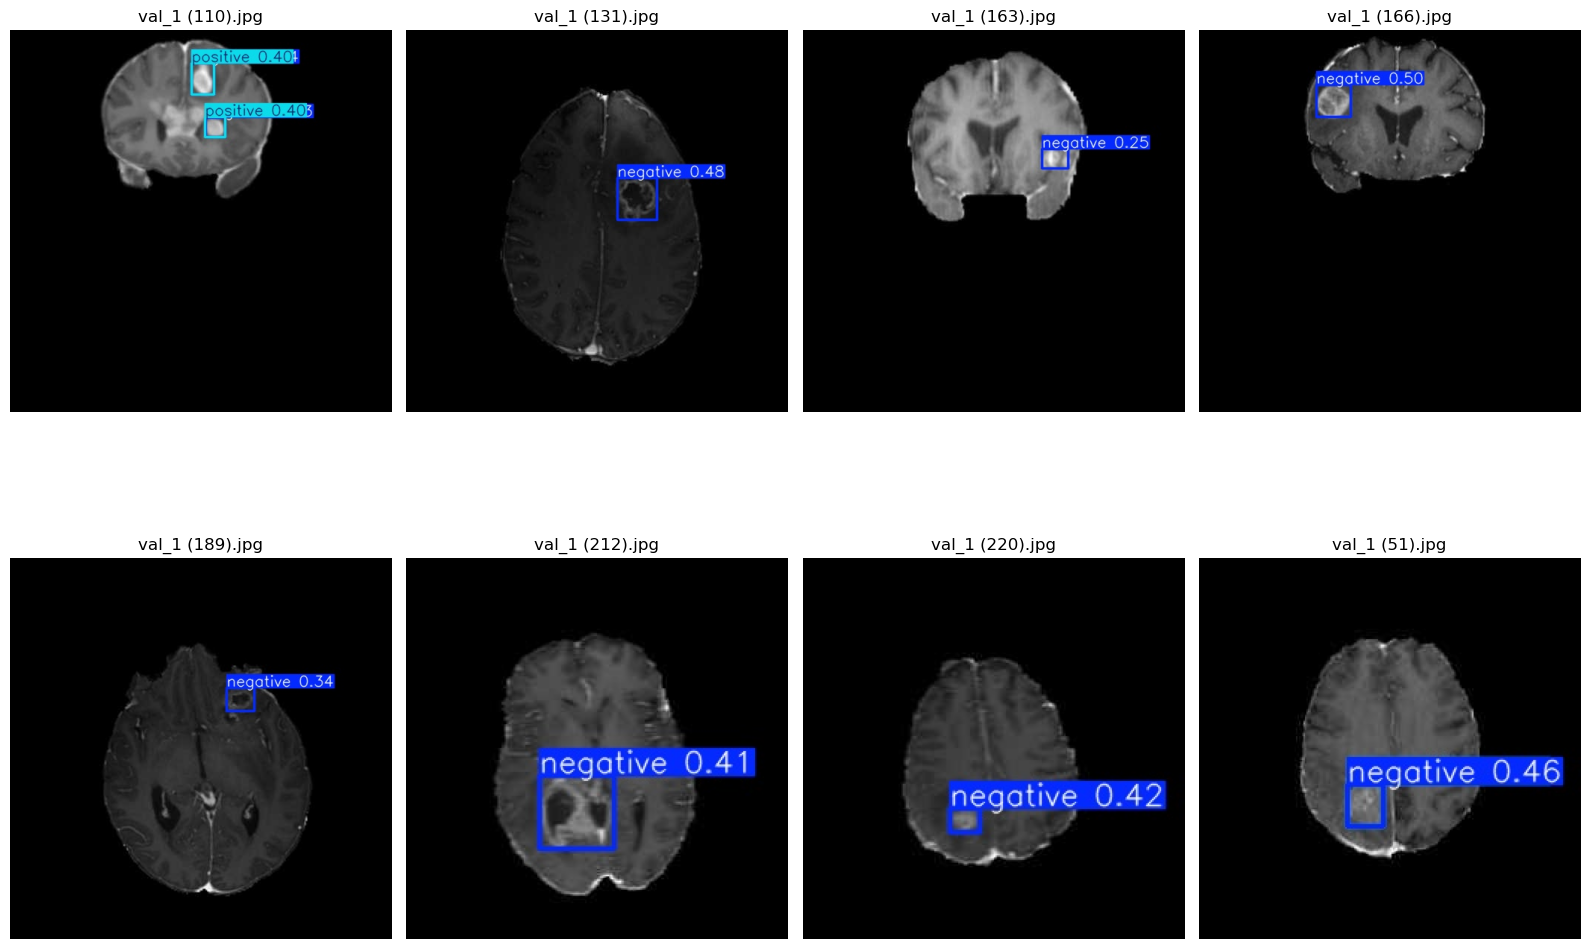

In [45]:
# En iyi model tarafından üretilen tahmin görsellerinin notebook içinde gösterilmesi.

plt.figure(figsize=(16, 12))

for index, image_path in enumerate(prediction_image_files[:8]):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2, 4, index + 1)
    plt.imshow(image)
    plt.title(image_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [46]:
# Tahmin sonuçlarında yer alan sınıf, güven skoru ve kutu bilgilerinin tabloya aktarılması.

prediction_rows = []

for result in prediction_results:
    image_name = Path(result.path).name
    
    if result.boxes is not None and len(result.boxes) > 0:
        for box in result.boxes:
            class_id = int(box.cls[0])
            confidence = float(box.conf[0])
            xyxy = box.xyxy[0].tolist()
            
            prediction_rows.append({
                "Görüntü": image_name,
                "Tahmin Edilen Sınıf ID": class_id,
                "Tahmin Edilen Sınıf": class_names[class_id],
                "Güven Skoru": round(confidence, 4),
                "x1": round(xyxy[0], 2),
                "y1": round(xyxy[1], 2),
                "x2": round(xyxy[2], 2),
                "y2": round(xyxy[3], 2)
            })
    else:
        prediction_rows.append({
            "Görüntü": image_name,
            "Tahmin Edilen Sınıf ID": None,
            "Tahmin Edilen Sınıf": "Tespit yok",
            "Güven Skoru": None,
            "x1": None,
            "y1": None,
            "x2": None,
            "y2": None
        })

df_predictions = pd.DataFrame(prediction_rows)
df_predictions

,Görüntü,Tahmin Edilen Sınıf ID,Tahmin Edilen Sınıf,Güven Skoru,x1,y1,x2,y2
0,val_1 (189).jpg,0,negative,0.3401,290.72,175.77,327.99,206.03
1,val_1 (212).jpg,0,negative,0.4056,89.53,146.68,139.83,195.33
2,val_1 (166).jpg,0,negative,0.4952,157.40,73.96,203.33,116.83
3,val_1 (220).jpg,0,negative,0.4165,98.03,168.46,118.65,184.48
4,val_1 (131).jpg,0,negative,0.4828,283.25,198.67,336.61,254.94
5,val_1 (51).jpg,0,negative,0.4634,99.21,152.11,123.22,180.09
6,val_1 (51).jpg,1,positive,0.2838,99.16,152.79,123.74,180.39
7,val_1 (163).jpg,0,negative,0.2517,320.63,159.53,355.57,185.65
8,val_1 (110).jpg,1,positive,0.4049,243.86,44.42,273.45,86.87
9,val_1 (110).jpg,1,positive,0.3967,261.84,116.86,288.92,143.10


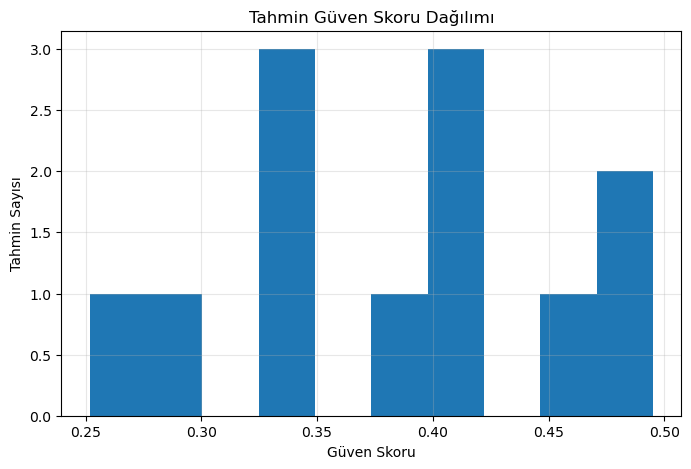

In [47]:
# Tahmin güven skorlarının dağılımının görselleştirilmesi.

valid_confidences = df_predictions.dropna(subset=["Güven Skoru"])

if len(valid_confidences) > 0:
    plt.figure(figsize=(8, 5))
    plt.hist(valid_confidences["Güven Skoru"], bins=10)
    plt.title("Tahmin Güven Skoru Dağılımı")
    plt.xlabel("Güven Skoru")
    plt.ylabel("Tahmin Sayısı")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("Güven skoru içeren tahmin bulunamadı.")

 Tahmin Sonuçları ve Model Güvenilirliği

En iyi model ağırlıkları (`best.pt`) kullanılarak doğrulama setinden seçilen örnek MR görüntüleri üzerinde tahminler gerçekleştirilmiştir. Elde edilen görseller incelendiğinde modelin bazı görüntülerde ilgili bölgeleri tespit edebildiği görülmektedir. Bununla birlikte bazı örneklerde birden fazla kutu üretildiği ve aynı görüntü üzerinde hem negatif hem pozitif sınıfa ait tahminlerin oluşabildiği gözlenmiştir.

Tahmin güven skorlarının çoğunlukla 0.25 ile 0.50 aralığında yoğunlaşması, modelin karar üretme kabiliyetine sahip olduğunu ancak tahmin güveninin henüz yüksek seviyede olmadığını göstermektedir. Bu durum, modelin sınıflar arasında ayrım yapabildiğini fakat bazı örneklerde kararsız kaldığını düşündürmektedir.

Elde edilen precision değerinin recall değerinden düşük olması da bu bulgularla uyumludur. Recall değerinin yüksek olması, modelin ilgili bölgeleri kaçırmama eğiliminin güçlü olduğunu göstermektedir. Ancak precision değerinin daha düşük olması, modelin yanlış pozitif tahmin üretme olasılığının bulunduğunu ortaya koymaktadır.

Sonuç olarak YOLOv8n modeli, Brain Tumor Detection veri seti üzerinde temel düzeyde tespit yapabilen bir başlangıç modeli olarak değerlendirilebilir. Ancak düşük-orta seviyedeki güven skorları, sınıflar arası karışmalar ve bazı örneklerde görülen çoklu tahminler nedeniyle modelin doğrudan klinik kullanım için yeterli güvenilirlikte olmadığı söylenebilir. Daha başarılı sonuçlar için daha büyük model varyantları, daha kapsamlı hiperparametre optimizasyonu, veri artırma yöntemleri ve daha dengeli veri yapısı ile ek çalışmalar yapılması önerilmektedir.

 8. Güven Eşiği Analizi ve Daha Güvenilir Tahmin Denemesi

Bu bölümde modelin farklı güven eşiklerinde nasıl davrandığı incelenecektir. Daha yüksek güven eşiği kullanıldığında yanlış pozitif tahminlerin azalması beklenir. Ancak eşik çok yükseltilirse model bazı gerçek bölgeleri kaçırabilir. Bu nedenle modelin güvenilirliği yalnızca tek bir eşik üzerinden değil, farklı eşik değerleri karşılaştırılarak değerlendirilecektir.

In [48]:
# Modelin farklı güven eşiklerinde doğrulama seti üzerinde değerlendirilmesi sağlanır.

confidence_values = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results = []

for confidence_value in confidence_values:
    validation_result = best_model.val(
        data=str(LOCAL_YAML_PATH),
        imgsz=416,
        batch=4,
        device="cpu",
        workers=0,
        conf=confidence_value,
        iou=0.5,
        plots=False,
        verbose=False,
        project="runs_brain_tumor",
        name=f"confidence_threshold_{str(confidence_value).replace('.', '_')}"
    )
    
    threshold_results.append({
        "Güven Eşiği": confidence_value,
        "Precision": round(float(validation_result.box.mp), 4),
        "Recall": round(float(validation_result.box.mr), 4),
        "mAP@0.5": round(float(validation_result.box.map50), 4),
        "mAP@0.5:0.95": round(float(validation_result.box.map), 4)
    })

df_threshold_results = pd.DataFrame(threshold_results)
df_threshold_results

Ultralytics 8.3.231 🚀 Python-3.13.5 torch-2.9.1 CPU (Apple M3)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 22.2±8.9 MB/s, size: 4.6 KB)
val: Scanning /Users/humahumeyraunal/brain_tumor_yolov8_final/labels/val.cache... 223 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 223/223 761.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 13.2it/s 4.2s0.1s
                   all        223        241      0.462      0.872      0.505      0.372
Speed: 0.2ms preprocess, 17.5ms inference, 0.0ms loss, 0.2ms postprocess per image
Ultralytics 8.3.231 🚀 Python-3.13.5 torch-2.9.1 CPU (Apple M3)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 135.3±72.9 MB/s, size: 2.6 KB)
val: Scanning /Users/humahumeyraunal/brain_tumor_yolov8_final/labels/val.cache... 223 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 223/223 1.6Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-9

,Güven Eşiği,Precision,Recall,mAP@0.5,mAP@0.5:0.95
0,0.25,0.4622,0.8725,0.5048,0.3724
1,0.30,0.4770,0.8399,0.4974,0.3695
2,0.35,0.4878,0.7442,0.4774,0.3620
3,0.40,0.5131,0.5363,0.4340,0.3358
4,0.45,0.4428,0.2405,0.3141,0.2464
5,0.50,0.3833,0.0747,0.2264,0.1789


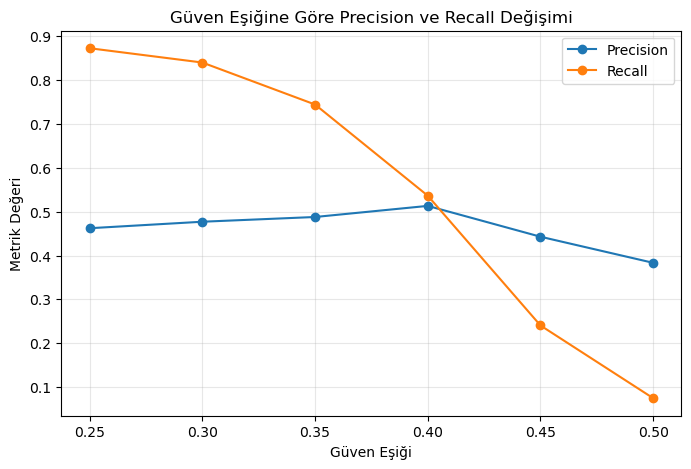

In [49]:
# Farklı güven eşiklerinde precision ve recall değişiminin görselleştirilmesi sağlanır.

plt.figure(figsize=(8, 5))

plt.plot(df_threshold_results["Güven Eşiği"], df_threshold_results["Precision"], marker="o", label="Precision")
plt.plot(df_threshold_results["Güven Eşiği"], df_threshold_results["Recall"], marker="o", label="Recall")

plt.title("Güven Eşiğine Göre Precision ve Recall Değişimi")
plt.xlabel("Güven Eşiği")
plt.ylabel("Metrik Değeri")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

 Güven Eşiği Analizi ile Model Güvenilirliğinin İncelenmesi

Bu bölümde eğitilen YOLOv8n modelinin yalnızca tek bir güven eşiğiyle değil, farklı güven eşiği değerleriyle nasıl sonuçlar verdiği incelenmiştir. Nesne tespiti modellerinde güven eşiği, modelin bir tahmini kabul etmek için ihtiyaç duyduğu minimum güven skorunu ifade eder. Bu eşik düşük tutulduğunda model daha fazla tahmin üretir; ancak yanlış pozitif tespitlerin artma ihtimali de yükselir. Güven eşiği artırıldığında ise model daha seçici davranır, fakat bu durumda bazı gerçek tümör bölgelerinin kaçırılması mümkündür.

Bu nedenle modelin güvenilirliğini daha ayrıntılı değerlendirmek amacıyla 0.25, 0.30, 0.35, 0.40, 0.45 ve 0.50 güven eşikleri kullanılarak doğrulama seti üzerinde ek değerlendirmeler yapılmıştır. Bu analiz sayesinde precision ve recall değerlerinin güven eşiğine bağlı olarak nasıl değiştiği gözlemlenmiştir.

Güven Eşiği Analizi Sonuçlarının Yorumu

Farklı güven eşiklerinde elde edilen sonuçlar incelendiğinde, güven eşiği yükseldikçe modelin daha seçici tahminler yaptığı görülmüştür. Düşük güven eşiğinde recall değerinin daha yüksek olması, modelin etiketli bölgeleri yakalama eğiliminin güçlü olduğunu göstermektedir. Ancak bu durumda precision değerinin daha sınırlı kalması, bazı tahminlerin yanlış pozitif olabileceğine işaret etmektedir.

0.25 güven eşiğinde model yüksek recall değeri üretmiş ve daha fazla olası tümör bölgesini tespit etmeye çalışmıştır. Buna karşılık 0.40 güven eşiğinde precision değerinin yükseldiği, fakat recall değerinin belirgin biçimde azaldığı görülmüştür. Bu durum, güven eşiğinin artırılmasının modeli daha seçici hale getirdiğini ancak bazı gerçek pozitif bölgelerin kaçırılmasına neden olabileceğini göstermektedir.

Bu çalışma kapsamında 0.35 güven eşiği, precision ve recall arasında daha dengeli bir ara değer sunduğu için ek tahmin görsellerinde kullanılmıştır. Böylece modelin daha düşük güvenli tahminleri elemesi ve daha güvenilir görünen tespitleri ön plana çıkarması amaçlanmıştır.

In [50]:
# Daha yüksek güven eşiği kullanılarak daha seçici tahminler üretilmesi sağlanır.

SELECTED_CONFIDENCE = 0.35

reliable_prediction_results = best_model.predict(
    source=[str(image_path) for image_path in sample_prediction_images],
    imgsz=416,
    conf=SELECTED_CONFIDENCE,
    iou=0.5,
    device="cpu",
    save=True,
    project="runs_brain_tumor",
    name="yolov8n_reliable_prediction_examples"
)

print("Daha yüksek güven eşiği ile tahmin işlemi tamamlandı.")


0: 416x416 (no detections), 16.5ms
1: 416x416 1 negative, 16.5ms
2: 416x416 1 negative, 16.5ms
3: 416x416 1 negative, 16.5ms
4: 416x416 1 negative, 16.5ms
5: 416x416 1 negative, 16.5ms
6: 416x416 (no detections), 16.5ms
7: 416x416 2 positives, 16.5ms
Speed: 0.7ms preprocess, 16.5ms inference, 0.2ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /Users/humahumeyraunal/brain_tumor_yolov8_final/runs_brain_tumor/yolov8n_reliable_prediction_examples
Daha yüksek güven eşiği ile tahmin işlemi tamamlandı.


 Daha Yüksek Güven Eşiği ile Tahmin Sonuçlarının Değerlendirilmesi

Daha yüksek güven eşiği kullanılarak yapılan tahminlerde modelin bazı düşük güvenli tespitleri elemiş olduğu görülmektedir. Bu durum, özellikle yanlış pozitif tahminlerin azaltılması açısından önemlidir. Ancak bazı görüntülerde hiç tespit yapılmaması, güven eşiği artırıldığında modelin daha temkinli davrandığını ve düşük güvenli bölgeleri tahmin olarak kabul etmediğini göstermektedir.

Tahmin görselleri incelendiğinde modelin bazı MR görüntülerinde tümör olduğu düşünülen bölgeler üzerine sınırlayıcı kutular yerleştirdiği görülmektedir. Bununla birlikte bazı tahminlerde güven skorlarının orta düzeyde kalması, modelin kararlarının kesin değil, olasılıksal olarak değerlendirilmesi gerektiğini göstermektedir. Bu nedenle model çıktıları doğrudan klinik karar amacıyla değil, yardımcı ve ön değerlendirme niteliğinde yorumlanmalıdır.

Bu ek analiz, modelin yalnızca genel başarı metrikleriyle değil, farklı karar eşikleri altında nasıl davrandığını göstermek açısından çalışmanın güvenilirliğini artırmıştır. Böylece modelin güçlü yönleri ve sınırlı kaldığı noktalar daha açık biçimde ortaya konulmuştur.

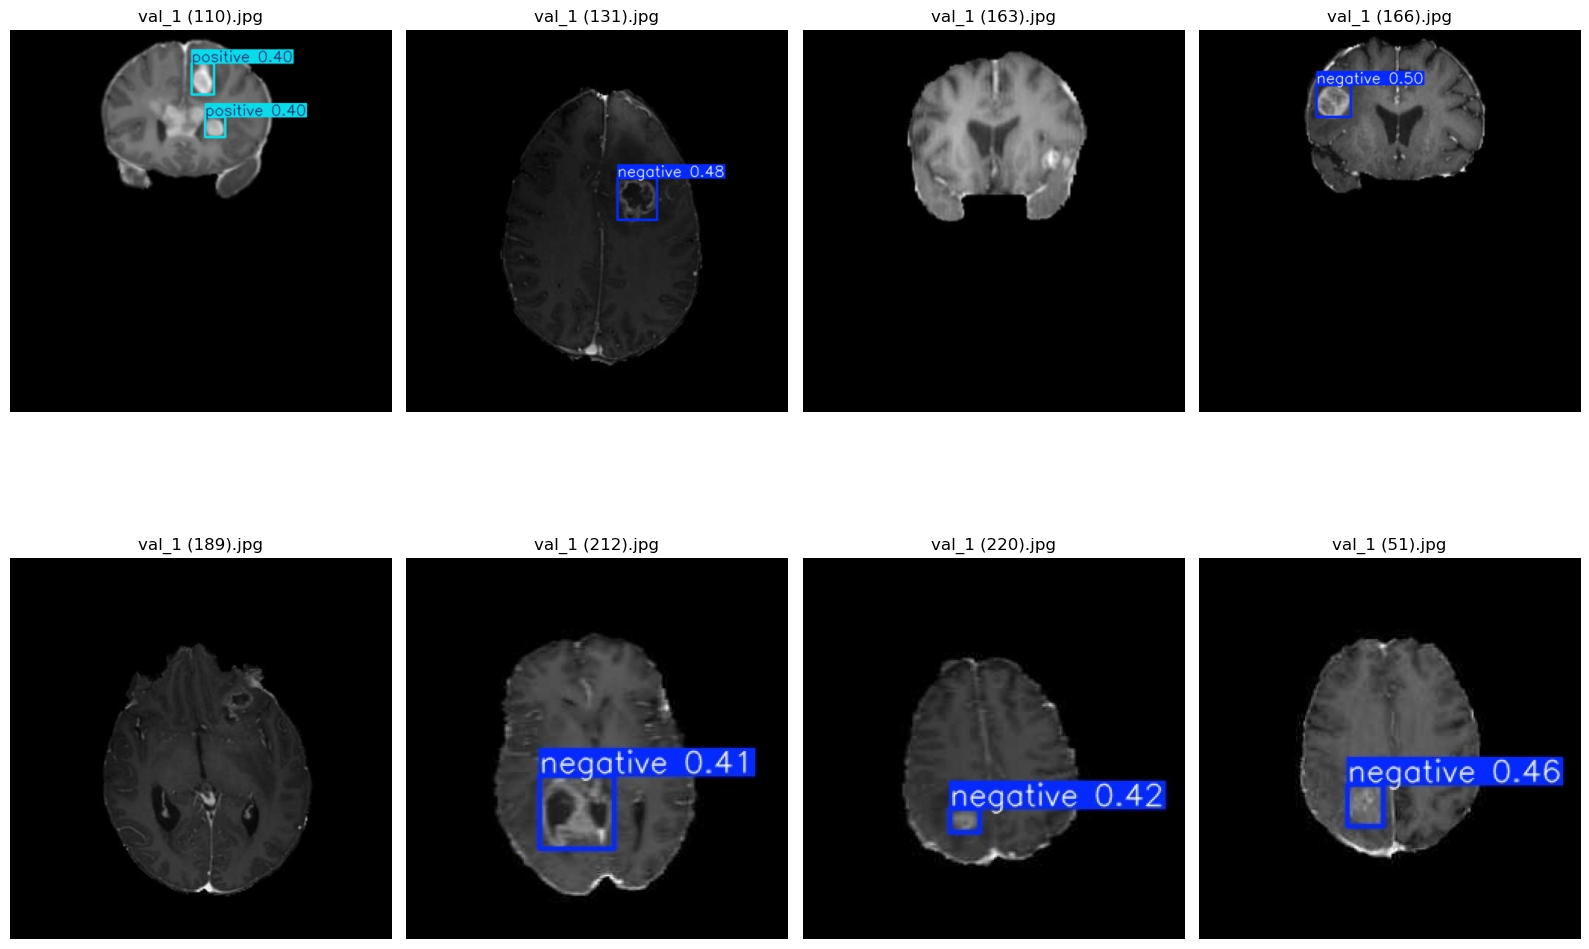

In [51]:
# Daha yüksek güven eşiği ile oluşturulan tahmin görsellerinin notebook içinde gösterilmesi sağlanır.

RELIABLE_PREDICTION_DIR = Path("runs_brain_tumor/yolov8n_reliable_prediction_examples")

reliable_prediction_image_files = sorted(
    list(RELIABLE_PREDICTION_DIR.glob("*.jpg")) +
    list(RELIABLE_PREDICTION_DIR.glob("*.png"))
)

plt.figure(figsize=(16, 12))

for index, image_path in enumerate(reliable_prediction_image_files[:8]):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2, 4, index + 1)
    plt.imshow(image)
    plt.title(image_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [52]:
# Çalışma sonunda üretilen temel dosya ve klasörlerin kontrol edilmesi.

final_files = {
    "Yerel YAML dosyası": LOCAL_YAML_PATH,
    "En iyi model ağırlığı": BEST_MODEL_PATH,
    "Son model ağırlığı": LAST_MODEL_PATH,
    "Eğitim sonuç CSV dosyası": RESULTS_CSV_PATH,
    "Eğitim sonuç grafiği": RESULTS_DIR / "results.png",
    "Karışıklık matrisi": RESULTS_DIR / "confusion_matrix.png",
    "Normalize karışıklık matrisi": RESULTS_DIR / "confusion_matrix_normalized.png",
    "Tahmin sonuç klasörü": PREDICTION_DIR,
    "Güven eşiği tahmin klasörü": RELIABLE_PREDICTION_DIR
}

for name, path in final_files.items():
    print(f"{name}: {'Var' if Path(path).exists() else 'Yok'}")

Yerel YAML dosyası: Var
En iyi model ağırlığı: Var
Son model ağırlığı: Var
Eğitim sonuç CSV dosyası: Var
Eğitim sonuç grafiği: Var
Karışıklık matrisi: Var
Normalize karışıklık matrisi: Var
Tahmin sonuç klasörü: Var
Güven eşiği tahmin klasörü: Var


 Kod Çalışmasının Tamamlanması

Bu aşamada veri hazırlama, model eğitimi, model değerlendirme, görselleştirme, tahmin üretme ve güven eşiği analizi adımları tamamlanmıştır. Üretilen model ağırlıkları, eğitim grafikleri, karışıklık matrisleri ve tahmin görselleri proje klasörü içinde kaydedilmiştir. Böylece çalışmanın kod uygulama kısmı tamamlanmış, elde edilen bulgular sonuç ve sınırlılıklar bölümünde yorumlanmıştır.

 9. Genel Sonuç, Sınırlılıklar ve Gelecek Çalışmalar

Bu çalışmada Brain Tumor Detection veri seti kullanılarak YOLOv8n tabanlı bir nesne tespiti modeli geliştirilmiştir. Çalışma kapsamında veri seti indirilmiş, klasör yapısı incelenmiş, görüntü ve etiket dosyalarının uyumu kontrol edilmiş, eksik etiket dosyaları için boş etiket dosyaları oluşturulmuş ve model eğitimi için uygun bir yerel YAML dosyası hazırlanmıştır. Daha sonra sınıf dağılımları analiz edilmiş, örnek görüntüler etiket kutuları ile birlikte görselleştirilmiş ve YOLOv8n modeli transfer öğrenme yaklaşımıyla eğitilmiştir.

Eğitim sonucunda en iyi model 24. epoch'ta elde edilmiştir. Modelin precision değeri 0.4633, recall değeri 0.8411, mAP@0.5 değeri 0.5042 ve mAP@0.5:0.95 değeri 0.3574 olarak bulunmuştur. Recall değerinin precision değerinden yüksek olması, modelin etiketli tümör bölgelerini yakalama eğiliminin güçlü olduğunu; ancak bazı yanlış pozitif tahminler üretme ihtimalinin de bulunduğunu göstermektedir. mAP@0.5 değerinin yaklaşık 0.50 seviyesinde olması, modelin temel düzeyde nesne tespiti yapabildiğini göstermektedir. Buna karşılık mAP@0.5:0.95 değerinin daha düşük olması, modelin daha sıkı IoU eşiklerinde kutu konumlandırma başarısının sınırlı kaldığını ortaya koymaktadır.

Model performansını daha ayrıntılı değerlendirmek amacıyla karışıklık matrisi, normalize edilmiş karışıklık matrisi, precision-recall eğrisi, F1-confidence eğrisi ve eğitim kayıp grafikleri incelenmiştir. Kayıp grafiklerinde eğitim ve doğrulama kayıplarının genel olarak azalma eğiliminde olduğu görülmüştür. Bu durum modelin veri setinden öğrenme gerçekleştirdiğini göstermektedir. Ancak karışıklık matrisi incelendiğinde negative ve positive sınıfları arasında karışmalar olduğu, ayrıca background sınıfı ile ilişkili hatalı veya eksik tespitlerin bulunduğu görülmüştür.

Çalışmanın son aşamasında farklı güven eşikleri kullanılarak ek analiz yapılmıştır. Bu analizde güven eşiği yükseldikçe modelin daha seçici hale geldiği, precision değerinin belirli bir noktaya kadar arttığı, ancak recall değerinin azaldığı gözlemlenmiştir. Bu durum nesne tespiti modellerinde güven eşiği seçiminin kritik olduğunu göstermektedir. Düşük güven eşiği daha fazla tespit üretirken yanlış pozitifleri artırabilmekte; yüksek güven eşiği ise daha güvenilir tahminler üretirken bazı gerçek bölgelerin kaçırılmasına neden olabilmektedir.

Bu çalışmanın bazı sınırlılıkları bulunmaktadır. İlk olarak model yalnızca YOLOv8n mimarisi ile eğitilmiştir. YOLOv8n hafif ve hızlı bir model olmasına rağmen daha karmaşık görüntü özelliklerini öğrenmede YOLOv8s, YOLOv8m veya daha büyük modeller kadar güçlü olmayabilir. İkinci olarak eğitim işlemi CPU üzerinde gerçekleştirildiği için daha büyük model, daha yüksek epoch sayısı ve daha yüksek görüntü boyutu gibi seçenekler sınırlı ölçüde denenebilmiştir. Üçüncü olarak veri setinde sınıflar arasında belirli dengesizlikler ve bazı görüntülerde boş etiket dosyaları bulunmaktadır. Bu durum modelin özellikle precision değerini ve sınıflar arası ayrım başarısını etkileyebilmektedir.

Gelecek çalışmalarda daha büyük YOLO modelleri kullanılarak karşılaştırmalı deneyler yapılabilir. Ayrıca görüntü boyutu artırılarak, hiperparametre optimizasyonu uygulanarak, veri artırma stratejileri kontrollü şekilde denenerek ve daha dengeli bir veri seti kullanılarak model başarısı geliştirilebilir. Bunun yanında yalnızca doğrulama seti değil, bağımsız bir test seti üzerinde de değerlendirme yapılması modelin genellenebilirliğini daha güvenilir biçimde ortaya koyacaktır.

Sonuç olarak geliştirilen YOLOv8n modeli, beyin MR görüntülerinde tümör bölgelerinin otomatik olarak tespit edilmesine yönelik temel düzeyde başarılı bir başlangıç modeli olarak değerlendirilebilir. Model özellikle yüksek recall değeri ile olası tümör bölgelerini yakalama konusunda güçlü bir eğilim göstermektedir. Ancak precision ve mAP@0.5:0.95 değerleri dikkate alındığında modelin klinik kullanım için tek başına yeterli olmadığı, daha kapsamlı veri, daha güçlü model mimarileri ve ek doğrulama deneyleri ile geliştirilmesi gerektiği sonucuna ulaşılmıştır.

Ek Analizlerin Çalışmaya Katkısı

Çalışmanın son bölümünde eklenen güven eşiği analizi ve daha seçici tahmin denemeleri, modelin yalnızca tek bir sonuç üzerinden değerlendirilmemesi için yapılmıştır. Nesne tespiti modellerinde model başarısı sadece eğitim sonunda elde edilen mAP değeriyle açıklanamaz. Modelin hangi güven eşiğinde daha fazla tahmin yaptığı, hangi eşikte daha seçici davrandığı ve precision-recall dengesinin nasıl değiştiği de önemlidir.

Bu nedenle farklı güven eşikleri denenmiş, elde edilen sonuçlar tablo ve grafiklerle gösterilmiş, ardından daha yüksek bir güven eşiği kullanılarak yeni tahmin görselleri üretilmiştir. Bu ek çalışmalar sayesinde modelin güçlü yönleri, zayıf yönleri ve güvenilir kullanım sınırları daha açık biçimde ortaya konulmuştur.